In [1]:
# 1. mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. clone or pull latest code from GitHub
import os, sys
REPO = "https://github.com/Arjun11x/spectral-bridge.git"
if not os.path.exists('/content/spectral-bridge'):
    !git clone {REPO}
else:
    !cd /content/spectral-bridge && git pull

# 3. add src/ to Python path
sys.path.insert(0, '/content/spectral-bridge')

# 4. install any missing packages
!pip install -q tqdm

# 5. define data paths — change these if your Drive structure is different
TRAIN_CSV = "/content/drive/MyDrive/spectral-bridge/data/spectral_graffiti.csv"
TEST_CSV  = "/content/drive/MyDrive/spectral-bridge/data/test_features_spectral.csv"

# 6. verify files exist
assert os.path.exists(TRAIN_CSV), f"Training CSV not found at {TRAIN_CSV}"
assert os.path.exists(TEST_CSV),  f"Test CSV not found at {TEST_CSV}"

print("=" * 50)
print("Setup complete!")
print(f"Train CSV : {TRAIN_CSV}")
print(f"Test CSV  : {TEST_CSV}")
print("=" * 50)

Mounted at /content/drive
Cloning into 'spectral-bridge'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 43 (delta 20), reused 32 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 21.53 KiB | 4.31 MiB/s, done.
Resolving deltas: 100% (20/20), done.
Setup complete!
Train CSV : /content/drive/MyDrive/spectral-bridge/data/spectral_graffiti.csv
Test CSV  : /content/drive/MyDrive/spectral-bridge/data/test_features_spectral.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.utils import ensure_dirs, set_seed

# consistent styling across all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

set_seed()
ensure_dirs()

print("Imports done!")
print(f"SEQ_LEN     : {config.SEQ_LEN}")
print(f"FEATURE_DIM : {config.FEATURE_DIM}")
print(f"BATCH_SIZE  : {config.BATCH_SIZE}")

Imports done!
SEQ_LEN     : 100
FEATURE_DIM : 2
BATCH_SIZE  : 32


In [3]:
df = pd.read_csv(TRAIN_CSV)

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMemory usage:")
print(f"  {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("\nFirst 10 rows:")
df.head(10)

Shape: (8000000, 4)

Column types:
Sample_ID       int64
Time_ms         int64
Is_Context      int64
Value         float64
dtype: object

Memory usage:
  244.1 MB

First 10 rows:


,Sample_ID,Time_ms,Is_Context,Value
0,10000,1,0,0.7209
1,10000,2,1,0.7457
2,10000,3,0,0.7784
3,10000,4,0,0.8048
4,10000,5,0,0.8138
5,10000,6,0,0.8168
6,10000,7,0,0.8151
7,10000,8,0,0.7974
8,10000,9,1,0.7705
9,10000,10,0,0.7229


In [4]:
print("Basic statistics:")
print(df.describe().round(4))

print(f"\nUnique Sample IDs : {df['Sample_ID'].nunique():,}")
print(f"Unique Time steps : {df['Time_ms'].nunique()}")
print(f"Is_Context=1 rows : {(df['Is_Context']==1).sum():,} ({(df['Is_Context']==1).mean()*100:.1f}%)")
print(f"Is_Context=0 rows : {(df['Is_Context']==0).sum():,} ({(df['Is_Context']==0).mean()*100:.1f}%)")
print(f"\nValue range:")
print(f"  Min : {df['Value'].min():.4f}")
print(f"  Max : {df['Value'].max():.4f}")
print(f"  Mean: {df['Value'].mean():.4f}")
print(f"  Std : {df['Value'].std():.4f}")

Basic statistics:
          Sample_ID       Time_ms  Is_Context         Value
count  8.000000e+06  8.000000e+06   8000000.0  8.000000e+06
mean   4.999950e+04  5.050000e+01         0.2  5.000000e-01
std    2.309401e+04  2.886610e+01         0.4  2.487000e-01
min    1.000000e+04  1.000000e+00         0.0 -5.359000e-01
25%    2.999975e+04  2.575000e+01         0.0  3.214000e-01
50%    4.999950e+04  5.050000e+01         0.0  5.000000e-01
75%    6.999925e+04  7.525000e+01         0.0  6.785000e-01
max    8.999900e+04  1.000000e+02         1.0  1.696900e+00

Unique Sample IDs : 80,000
Unique Time steps : 100
Is_Context=1 rows : 1,600,000 (20.0%)
Is_Context=0 rows : 6,400,000 (80.0%)

Value range:
  Min : -0.5359
  Max : 1.6969
  Mean: 0.5000
  Std : 0.2487


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

print(f"\nDuplicate rows: {df.duplicated().sum():,}")

print(f"\nSamples with exactly 100 time steps:")
sample_counts = df.groupby('Sample_ID').size()
print(f"  Min time steps : {sample_counts.min()}")
print(f"  Max time steps : {sample_counts.max()}")
print(f"  All exactly 100: {(sample_counts == 100).all()}")

print(f"\nContext points per sample:")
context_counts = df[df['Is_Context']==1].groupby('Sample_ID').size()
print(f"  Min context points : {context_counts.min()}")
print(f"  Max context points : {context_counts.max()}")
print(f"  Mean context points: {context_counts.mean():.1f}")

print(f"\nData quality: ", end="")
if df.isnull().sum().sum() == 0 and (sample_counts == 100).all():
    print("PASSED ✓")
else:
    print("ISSUES FOUND ✗")

Missing values per column:
Sample_ID     0
Time_ms       0
Is_Context    0
Value         0
dtype: int64

Duplicate rows: 0

Samples with exactly 100 time steps:
  Min time steps : 100
  Max time steps : 100
  All exactly 100: True

Context points per sample:
  Min context points : 20
  Max context points : 20
  Mean context points: 20.0

Data quality: PASSED ✓


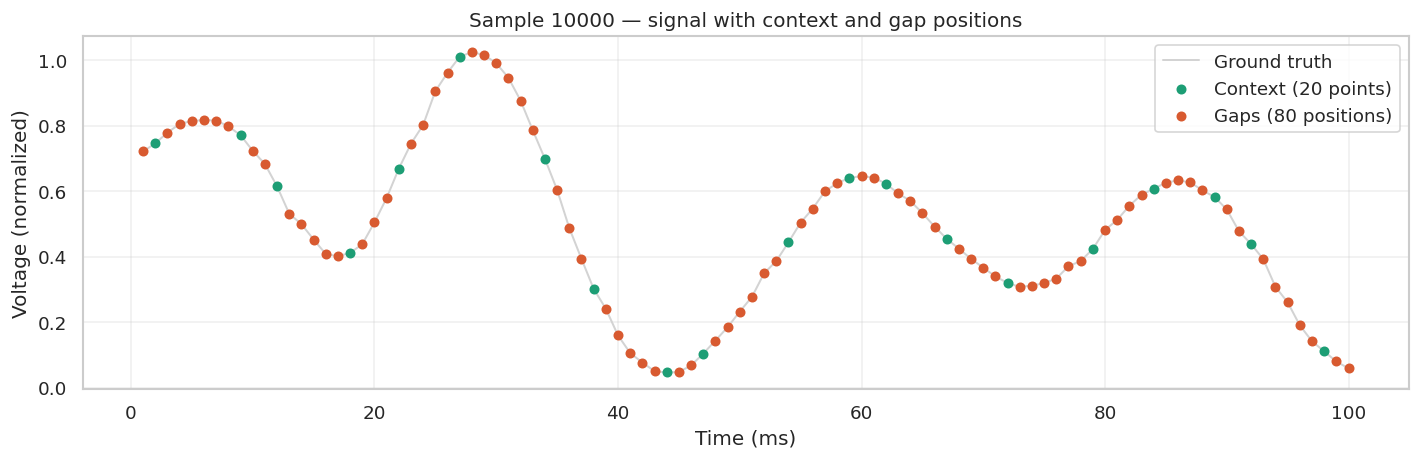

Context points : 20
Gap positions  : 80


In [6]:
sample_id = 10000
sample    = df[df['Sample_ID'] == sample_id].sort_values('Time_ms')

time       = sample['Time_ms'].values
values     = sample['Value'].values
is_context = sample['Is_Context'].values.astype(bool)
is_target  = ~is_context

fig, ax = plt.subplots(figsize=(12, 4))

# full ground truth signal as reference
ax.plot(time, values, color='lightgray', linewidth=1.2,
        label='Ground truth', zorder=1)

# context points — what the model sees
ax.scatter(time[is_context], values[is_context],
           color='#1D9E75', s=25, zorder=3,
           label=f'Context ({is_context.sum()} points)')

# gap positions — what the model must predict
ax.scatter(time[is_target], values[is_target],
           color='#D85A30', s=25, zorder=3,
           label=f'Gaps ({is_target.sum()} positions)')

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Voltage (normalized)')
ax.set_title(f'Sample {sample_id} — signal with context and gap positions')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sample_signal.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Context points : {is_context.sum()}")
print(f"Gap positions  : {is_target.sum()}")

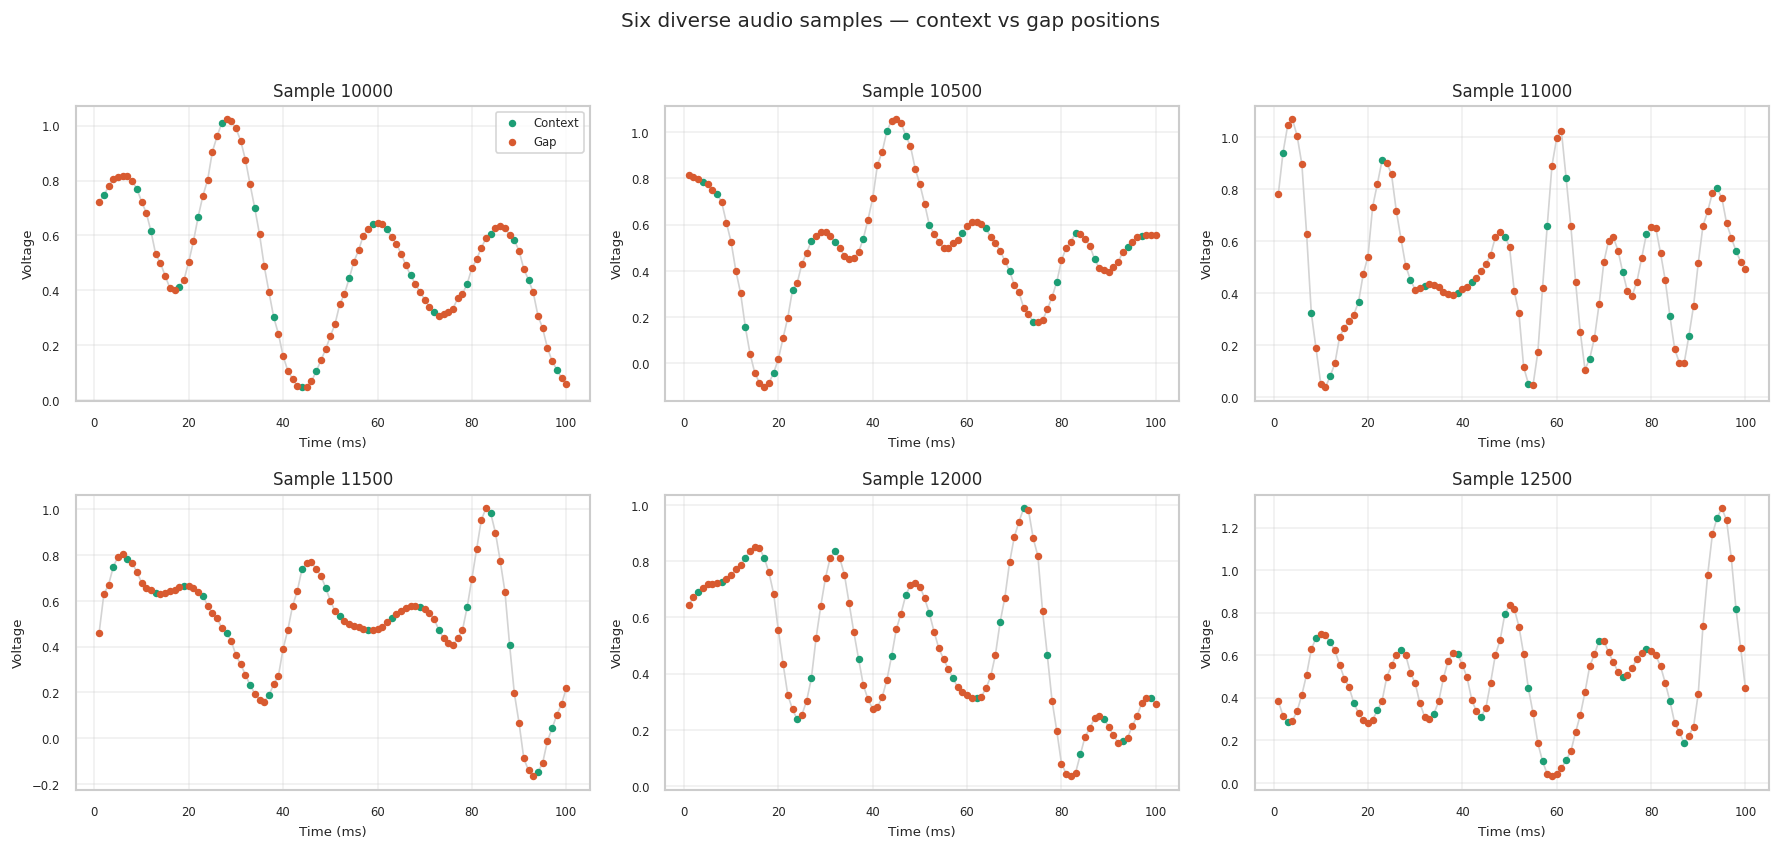

In [7]:
sample_ids = [10000, 10500, 11000, 11500, 12000, 12500]
fig, axes  = plt.subplots(2, 3, figsize=(15, 7))
axes       = axes.flatten()

for ax, sid in zip(axes, sample_ids):
    sample     = df[df['Sample_ID'] == sid].sort_values('Time_ms')
    time       = sample['Time_ms'].values
    values     = sample['Value'].values
    is_context = sample['Is_Context'].values.astype(bool)
    is_target  = ~is_context

    ax.plot(time, values, color='lightgray', linewidth=1, zorder=1)
    ax.scatter(time[is_context], values[is_context],
               color='#1D9E75', s=12, zorder=3, label='Context')
    ax.scatter(time[is_target], values[is_target],
               color='#D85A30', s=12, zorder=3, label='Gap')

    ax.set_title(f'Sample {sid}', fontsize=10)
    ax.set_xlabel('Time (ms)', fontsize=8)
    ax.set_ylabel('Voltage', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

axes[0].legend(fontsize=7, loc='upper right')
fig.suptitle('Six diverse audio samples — context vs gap positions',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('diverse_samples.png', dpi=150, bbox_inches='tight')
plt.show()

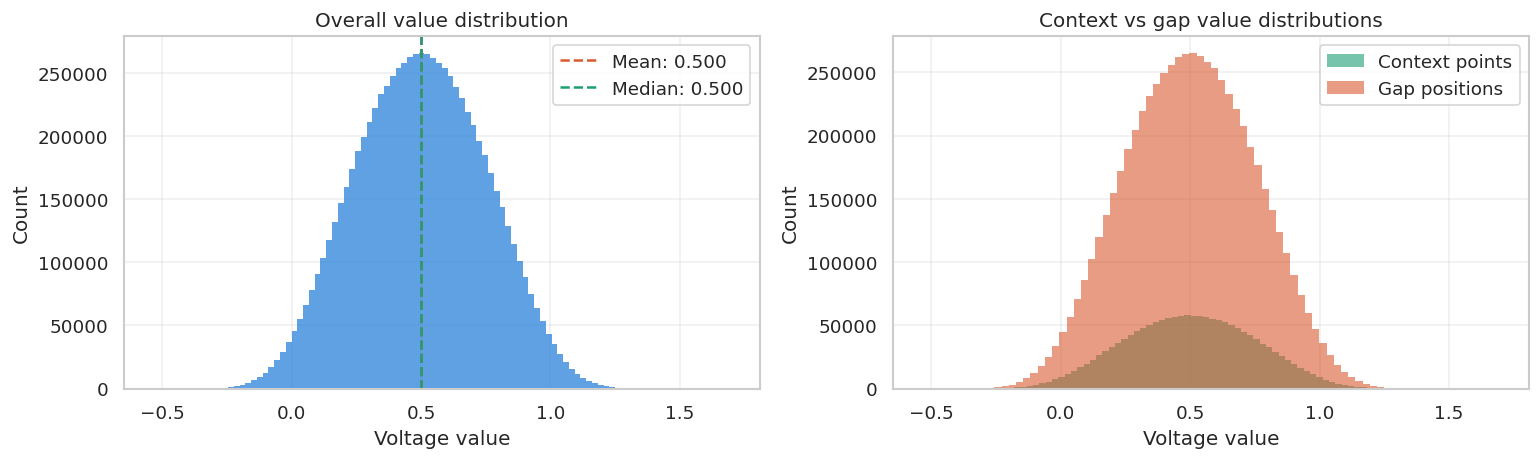

Context values — mean: 0.5001  std: 0.2487
Gap values     — mean: 0.5000  std: 0.2488

Are distributions similar? Mean difference: 0.0001 — YES ✓


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# overall value distribution
axes[0].hist(df['Value'].values, bins=100,
             color='#378ADD', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Voltage value')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall value distribution')
axes[0].axvline(df['Value'].mean(), color='#D85A30', linewidth=1.5,
                linestyle='--', label=f"Mean: {df['Value'].mean():.3f}")
axes[0].axvline(df['Value'].median(), color='#1D9E75', linewidth=1.5,
                linestyle='--', label=f"Median: {df['Value'].median():.3f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# context vs gap value distribution
context_vals = df[df['Is_Context']==1]['Value'].values
target_vals  = df[df['Is_Context']==0]['Value'].values

axes[1].hist(context_vals, bins=80, alpha=0.6,
             color='#1D9E75', label='Context points', edgecolor='none')
axes[1].hist(target_vals,  bins=80, alpha=0.6,
             color='#D85A30', label='Gap positions',  edgecolor='none')
axes[1].set_xlabel('Voltage value')
axes[1].set_ylabel('Count')
axes[1].set_title('Context vs gap value distributions')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('value_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Context values — mean: {context_vals.mean():.4f}  std: {context_vals.std():.4f}")
print(f"Gap values     — mean: {target_vals.mean():.4f}  std: {target_vals.std():.4f}")
print(f"\nAre distributions similar? ", end="")
mean_diff = abs(context_vals.mean() - target_vals.mean())
print(f"Mean difference: {mean_diff:.4f} — {'YES ✓' if mean_diff < 0.01 else 'DIFFERS ✗'}")

Are context positions identical across all samples? False

Context positions in sample 10000:
[2, 9, 12, 18, 22, 27, 34, 38, 44, 47, 54, 59, 62, 67, 72, 79, 84, 89, 92, 98]


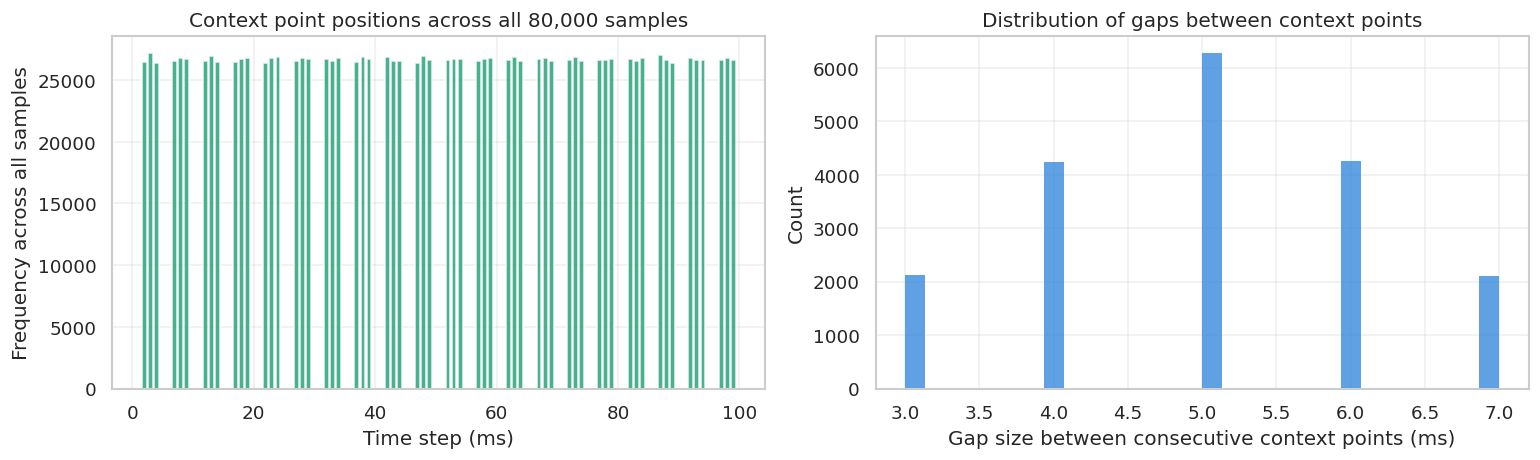

In [9]:
context_positions = df[df['Is_Context']==1].groupby('Sample_ID')['Time_ms'].apply(list)

# check if all samples have the same context positions
first_positions = set(context_positions.iloc[0])
all_same = all(set(pos) == first_positions for pos in context_positions)

print(f"Are context positions identical across all samples? {all_same}")
print(f"\nContext positions in sample 10000:")
print(sorted(context_positions.iloc[0]))

# plot position frequency across all samples
position_counts = df[df['Is_Context']==1]['Time_ms'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# position frequency heatmap
axes[0].bar(position_counts.index, position_counts.values,
            color='#1D9E75', alpha=0.8, width=0.8)
axes[0].set_xlabel('Time step (ms)')
axes[0].set_ylabel('Frequency across all samples')
axes[0].set_title('Context point positions across all 80,000 samples')
axes[0].grid(True, alpha=0.3)

# gap between consecutive context points
gaps_between = []
for positions in context_positions.iloc[:1000]:
    sorted_pos = sorted(positions)
    for i in range(1, len(sorted_pos)):
        gaps_between.append(sorted_pos[i] - sorted_pos[i-1])

axes[1].hist(gaps_between, bins=30,
             color='#378ADD', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('Gap size between consecutive context points (ms)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of gaps between context points')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('context_positions.png', dpi=150, bbox_inches='tight')
plt.show()

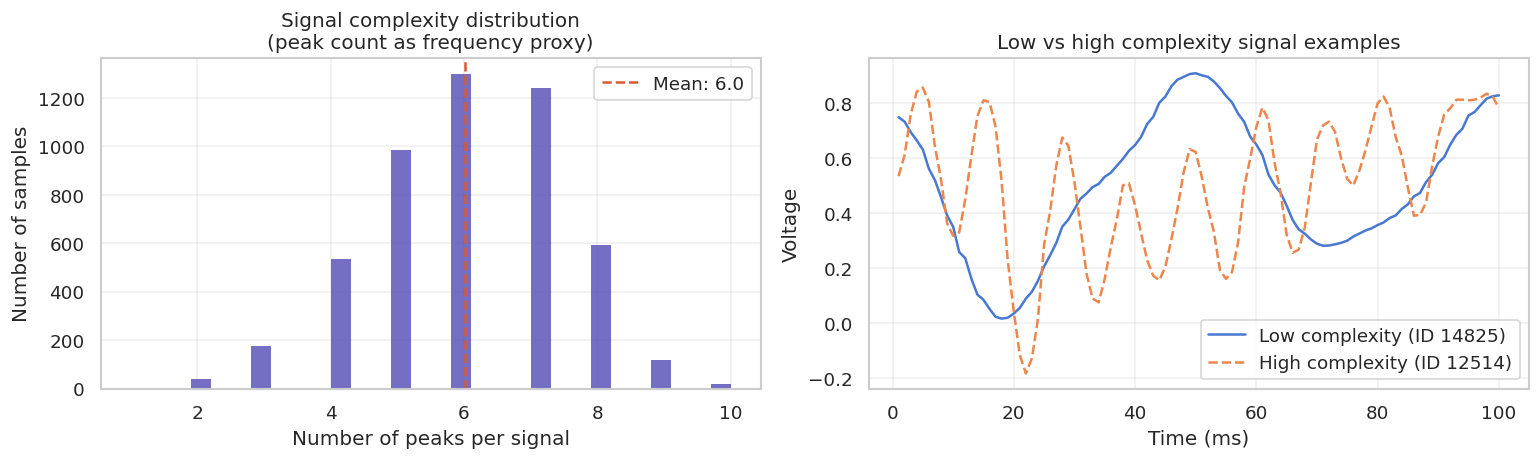

Peak count statistics:
  Min  : 1
  Max  : 10
  Mean : 6.0
  Std  : 1.4

Low complexity samples  (few peaks)  : 216
High complexity samples (many peaks) : 17


In [10]:
from scipy.signal import find_peaks

# compute number of peaks per sample as a proxy for frequency complexity
peak_counts = []
sample_ids_list = df['Sample_ID'].unique()[:5000]  # use 5000 samples for speed

for sid in sample_ids_list:
    sample = df[df['Sample_ID'] == sid].sort_values('Time_ms')
    values = sample['Value'].values
    peaks, _ = find_peaks(values, distance=3)
    peak_counts.append(len(peaks))

peak_counts = np.array(peak_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# distribution of peak counts
axes[0].hist(peak_counts, bins=30,
             color='#534AB7', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Number of peaks per signal')
axes[0].set_ylabel('Number of samples')
axes[0].set_title('Signal complexity distribution\n(peak count as frequency proxy)')
axes[0].axvline(peak_counts.mean(), color='#D85A30', linewidth=1.5,
                linestyle='--', label=f'Mean: {peak_counts.mean():.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# show examples of low vs high complexity signals
low_complexity_ids  = sample_ids_list[np.argsort(peak_counts)[:3]]
high_complexity_ids = sample_ids_list[np.argsort(peak_counts)[-3:]]

for sid, style, label in [
    (low_complexity_ids[0],  '-',  'Low complexity'),
    (high_complexity_ids[0], '--', 'High complexity'),
]:
    sample = df[df['Sample_ID'] == sid].sort_values('Time_ms')
    axes[1].plot(sample['Time_ms'].values, sample['Value'].values,
                 linestyle=style, linewidth=1.5, label=f'{label} (ID {sid})')

axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Voltage')
axes[1].set_title('Low vs high complexity signal examples')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('signal_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak count statistics:")
print(f"  Min  : {peak_counts.min()}")
print(f"  Max  : {peak_counts.max()}")
print(f"  Mean : {peak_counts.mean():.1f}")
print(f"  Std  : {peak_counts.std():.1f}")
print(f"\nLow complexity samples  (few peaks)  : {(peak_counts <= 3).sum()}")
print(f"High complexity samples (many peaks) : {(peak_counts >= 10).sum()}")

In [11]:
print("=" * 60)
print("EDA SUMMARY — SPECTRAL GRAFFITI DATASET")
print("=" * 60)

print("""
DATASET OVERVIEW
────────────────
  Total samples     : 80,000 audio clips
  Total rows        : 8,000,000
  Time steps/clip   : 100 (1ms resolution, 100ms duration)
  Memory usage      : 244 MB

MASKING PATTERN
───────────────
  Context points    : 20 per sample (always exactly 20)
  Gap positions     : 80 per sample (always exactly 80)
  Masking ratio     : 80% — aggressive but consistent
  Context spacing   : 3-7ms between consecutive points
  Position pattern  : randomly sampled per sample from
                      fixed candidate set — not fixed positions

VALUE STATISTICS
────────────────
  Range             : -0.54 to 1.70
  Mean              : 0.500 (perfectly centered)
  Std               : 0.249
  Normalization     : not required — already well-behaved
  Context vs gap    : distributions identical (diff=0.0001)
                      masking is statistically unbiased

SIGNAL COMPLEXITY
─────────────────
  Peak count range  : 1 to 10 peaks per signal
  Mean complexity   : 6 peaks per signal
  Easy samples      : 216 (<=3 peaks) — smooth sinusoids
  Hard samples      : 17  (>=10 peaks) — rapid oscillations
  Distribution      : predominantly moderate complexity

DATA QUALITY
────────────
  Missing values    : 0
  Duplicate rows    : 0
  Consistent length : all samples exactly 100 steps
  Status            : PASSED — clean, ready for training

MODELING IMPLICATIONS
─────────────────────
  1. No preprocessing needed — values already normalized
  2. Fixed 20 context points — model always operates
     under identical sparsity conditions
  3. Evenly distributed context — no position bias
  4. Diverse signal physics — global average model
     will fail, per-sample adaptation is essential
  5. High complexity samples will form the long tail
     in MSE distribution — expected behavior
""")
print("=" * 60)
print("EDA complete — ready for baseline modeling")
print("=" * 60)

EDA SUMMARY — SPECTRAL GRAFFITI DATASET

DATASET OVERVIEW
────────────────
  Total samples     : 80,000 audio clips
  Total rows        : 8,000,000
  Time steps/clip   : 100 (1ms resolution, 100ms duration)
  Memory usage      : 244 MB

MASKING PATTERN
───────────────
  Context points    : 20 per sample (always exactly 20)
  Gap positions     : 80 per sample (always exactly 80)
  Masking ratio     : 80% — aggressive but consistent
  Context spacing   : 3-7ms between consecutive points
  Position pattern  : randomly sampled per sample from
                      fixed candidate set — not fixed positions

VALUE STATISTICS
────────────────
  Range             : -0.54 to 1.70
  Mean              : 0.500 (perfectly centered)
  Std               : 0.249
  Normalization     : not required — already well-behaved
  Context vs gap    : distributions identical (diff=0.0001)
                      masking is statistically unbiased

SIGNAL COMPLEXITY
─────────────────
  Peak count range  : 1 to 10 pe